In [1]:
from spin_lattices import KagomeLattice, SpinLattice, ChainLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
import networkx as nx
import numpy as np
from typing import Callable
import torch
import numpy.typing as npt
import lattice_symmetries as ls
from typing import Any, Optional, Union, Dict, Tuple
from loguru import logger
from collections import namedtuple
from torch import Tensor
import torch.nn as nn
from misc_utils import make_unpacked_configurations
import io
from contextlib import redirect_stderr
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from nqs_playground_helpers import (
    SamplingOptions,
    split_into_batches,
    safe_exp,
    sample_exactly,
    sample_full,
    forward_with_batches,
)
from scipy.sparse import csr_matrix, coo_matrix, diags
from scipy.sparse.csgraph import connected_components
import sys
from kagome_cnn import KagomeCNNRegression
from torch.nn.utils.convert_parameters import parameters_to_vector, vector_to_parameters
import time
from scipy.optimize import minimize
from vmc_amplitude import almost_true_relsigns
from vmc_vs_lbfgs import ScipyOptimizer
import fire
from my_stopwatch import stopwatch
from vmc_vs_lbfgs_2023_08_02 import LogProbDenseNet
from slater_determinant import SlaterDeterminant, Initializer
import matplotlib.pyplot as plt
logger.remove()
logger.add(sys.stderr, level="INFO")

2023-08-07 18:13:46.847 | DEBUG    | lattice_symmetries:__init__:50 - Initializing Haskell runtime...
2023-08-07 18:13:46.851 | DEBUG    | lattice_symmetries:__init__:52 - Initializing Chapel runtime...
2023-08-07 18:13:46.896 | DEBUG    | lattice_symmetries:__init__:54 - Setting Python exception handler...
set_python_exception_handler ...


2

In [2]:
class SlaterDet(nn.Module):
    def __init__(
        self,
        system: SpinSystem,
        initialization: str | Initializer = "orthogonal",
        postprocessor=None,
    ):
        super().__init__()
        self.det = SlaterDeterminant(
            lattice=system.lattice,
            basis=system.canonical_basis,
            initialization=initialization,
            sign_cache_dir=Path("signs_cache"),
        )
        self.system = system
        self.postprocessor = postprocessor

    def forward(self, states: torch.Tensor | npt.NDArray):
        if isinstance(states, np.ndarray):
            states = torch.from_numpy(states.astype(np.int64))
        indices = self.system.canonical_basis.index(states.detach().numpy().astype(np.uint64))
        assert isinstance(indices, np.ndarray)
        indices = torch.from_numpy(indices.astype(np.int64))
        ret = ((self.det.forward(indices))).view(-1, 1)
        if self.postprocessor is not None:
            return self.postprocessor(ret)
        return ret

In [7]:
stopwatch.reset()
lattice = KagomeLattice(2, 3)
system = HeisenbergJ1J2(
    lattice=lattice,
    J1=1,
    J2=1,
    use_symmetries=False,
    spin_inversion=None,
    ground_state_cache_dir=Path("groundstates"),
)
logger.info(f"System: {system.get_cache_id()}")

energy, _ = system.get_eigenstates(1)
log_prob_fn = LogProbDenseNet(system, n_hidden=512, hidden_layers=1)

# log_prob_fn = SlaterDet(system, postprocessor=lambda x: torch.log(torch.abs(x)))

logger.info(f"True energy: {energy[0]}")

writer = SummaryWriter(
    log_dir=(
        f"experiments/{datetime.now().strftime('%Y_%m_%d')}/{datetime.now().strftime('%H_%M_%S')}"
    )
)

optimizer = ScipyOptimizer(
    system=system,
    log_prob_fn=log_prob_fn,
    method="L-BFGS-B",
    maxiter=100000,
    batch_size=8096,
    tb_writer=writer,
    clip_grad_norm=0.02,
    clip_grad_norm_type='inf',
    # annealing_steps=0, #240,
    # initial_temp=2,
    # sign_noise_annealing_steps=10,
    # sign_noise_initial_eps=0.2,
)
try:
    r = optimizer.optimize()
    print(r)
finally:
    logger.info(str(stopwatch))


[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-08-07 18:41:35.451 | INFO     | __main__:<module>:11 - System: HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-False-None
2023-08-07 18:41:35.455 | INFO     | __main__:<module>:18 - True energy: -32.19308309416496
2023-08-07 18:41:36.095 | INFO     | vmc_vs_lbfgs:objective:180 - -13.867867469787598
2023-08-07 18:41:36.339 | INFO     | vmc_vs_lbfgs:objective:180 - -14.966832160949707
2023-08-07 18:41:36.577 | INFO     | vmc_vs_lbfgs:objective:180 - -20.589149475097656
2023-08-07 18:41:36.789 | INFO     | vmc_vs_lbfgs:objective:180 - -0.14573854207992554
2023-08-07 18:41:37.007 | INFO     | vmc_vs_lbfgs:objective:180 - -20.76333236694336
2023-08-07 18:41:37.220 | INFO     | vmc_vs_lbfgs:objective:180 - -20.92974281311035
2023-08-07 18:41:37.437 | INFO     | vmc_vs_lbfgs:objective:180 - -16.603296279907227
2023-08-07 18:41:37.647 | INFO     | vmc_vs_lbfgs:objective:180 - -21.10689353942871
2023-08-07 18:41:37.860 | INFO     | vmc_vs

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -31.94857406616211
        x: [-3.949e-01  1.362e-01 ...  9.365e-01 -1.312e-02]
      nit: 4259
      jac: [-1.317e-03  1.093e-03 ...  2.832e-03 -1.125e-06]
     nfev: 6202
     njev: 6202
 hess_inv: <10241x10241 LbfgsInvHessProduct with dtype=float64>


In [ ]:
predictions = log_prob_fn(system.canonical_basis.states).detach().numpy().flatten()

In [ ]:
true_log_amplitudes = np.log(np.abs(system.get_ground_state_coeffs(system.canonical_basis.states)))

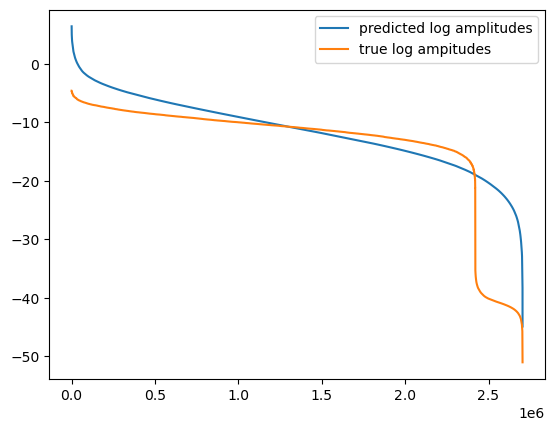

<Axes: xlabel='emb_x', ylabel='emb_y'>

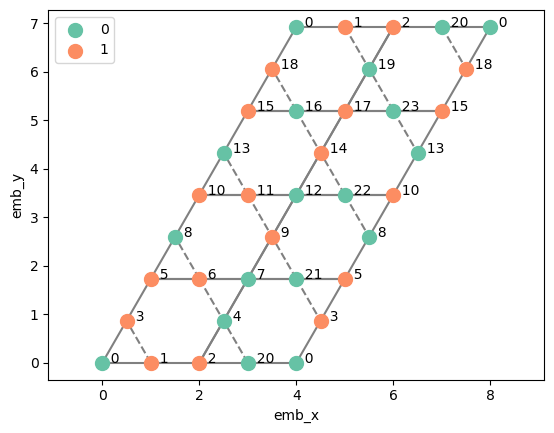

In [ ]:
lattice.plot(spins=system.canonical_basis.states[predictions.argsort()[-3]])